=== Dynamic Quantum Lyapunov Synthesis with BH at Every Step ===
=== Second-order MAS with linear + quadratic drag ===

=== Decision step 1/100 ===
   Updated parameter ranges after BH:
      Kp: [2.008, 3.676] (width=1.668)
      Kd: [12.877, 15.739] (width=2.862)
      theta_x2: [10.124, 12.223] (width=2.099)
      theta_v2: [12.195, 15.395] (width=3.200)
      theta_x4: [4.356, 7.404] (width=3.049)
   Selected params: s=0000000000, Kp=2.008, Kd=12.877, theta_x2=10.124, theta_v2=12.195, theta_x4=4.356, J=158.7716
   State at end of interval: x=[ 4.74403982 -3.58720574  2.84230243 -1.78133595  1.00001037], v=[-0.55606682  0.72947053 -0.26731354  0.44970244  0.02272502]
   Consensus error sqrt(||Lx||^2 + ||Lv||^2) = 2.355e+01

=== Decision step 2/100 ===
   Updated parameter ranges after BH:
      Kp: [2.073, 2.827] (width=0.754)
      Kd: [13.295, 15.209] (width=1.914)
      theta_x2: [10.205, 11.903] (width=1.697)
      theta_v2: [12.904, 14.802] (width=1.898)
      theta_x4: [4.587,

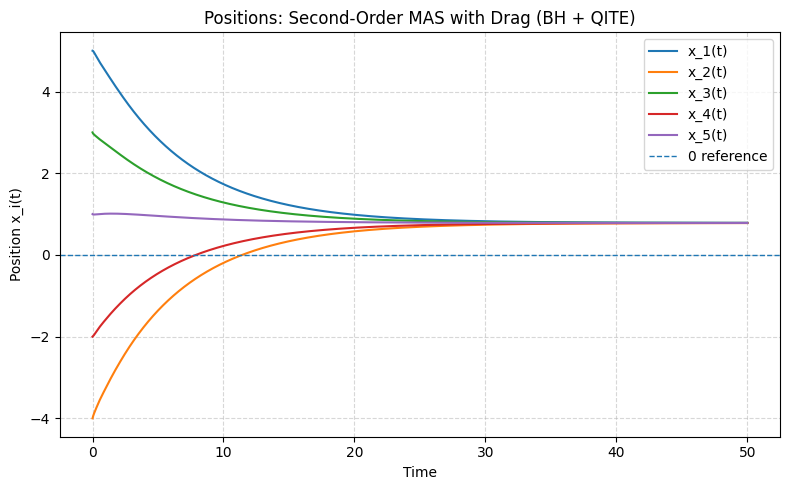

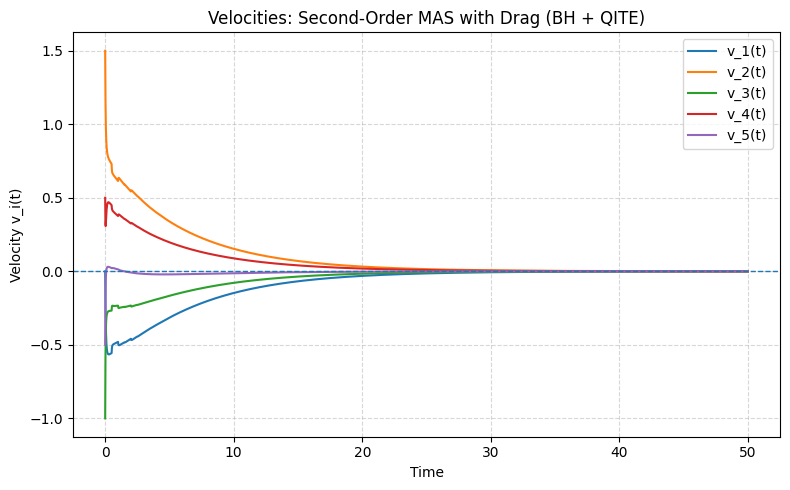

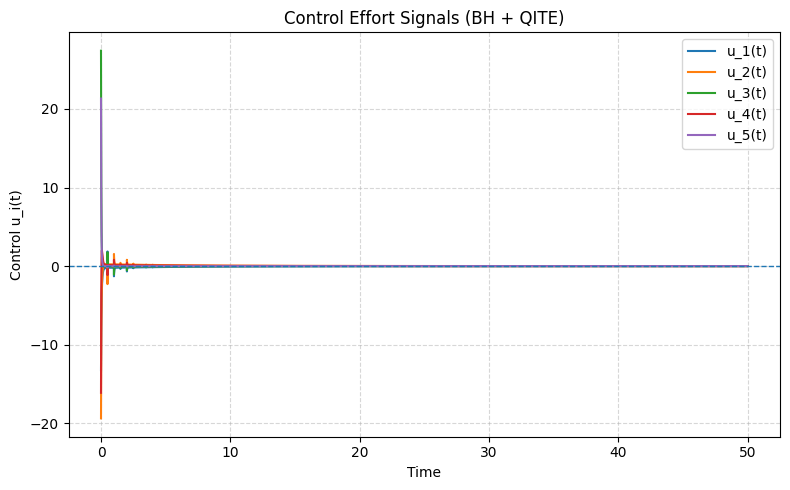


Final states at t = 50.0000:
  Agent 1: x_1(T) = 7.851982e-01, v_1(T) = -2.919049e-04
  Agent 2: x_2(T) = 7.814294e-01, v_2(T) = 2.957444e-04
  Agent 3: x_3(T) = 7.842478e-01, v_3(T) = -1.455612e-04
  Agent 4: x_4(T) = 7.822200e-01, v_4(T) = 1.719226e-04
  Agent 5: x_5(T) = 7.835221e-01, v_5(T) = -3.020354e-05

Final consensus error:
  sqrt(||Lx(T)||_2^2 + ||Lv(T)||_2^2) = 0.010506253562487435

Final parameter ranges after last BH:
  Kp: [2.209, 2.209]
  Kd: [14.042, 14.042]
  theta_x2: [10.700, 10.700]
  theta_v2: [14.172, 14.172]
  theta_x4: [4.979, 4.979]


In [1]:
import numpy as np
from itertools import product
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import Estimator
from qiskit.circuit.library import EfficientSU2
from qiskit_algorithms import VarQITE
from qiskit_algorithms.time_evolvers import TimeEvolutionProblem
from qiskit_algorithms.time_evolvers.variational import ImaginaryMcLachlanPrinciple

# ============================================================
# GLOBAL CONFIGURATION (EASY TO MODIFY)
# ============================================================

VERBOSE = False  # set True for detailed debug prints

# ----- Multi-Agent System -----
N_AGENTS = 5

# Ring topology adjacency matrix
A = np.array([
    [0, 1, 0, 0, 1],
    [1, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 1],
    [1, 0, 0, 1, 0],
], dtype=float)

D = np.diag(A.sum(axis=1))
L = D - A

# ----- Physical drag coefficients (fixed, "real" plant parameters) -----
A_DRAG_LIN = 0.5    # linear drag coefficient a
B_DRAG_QUAD = 0.05  # quadratic drag coefficient b

# ----- Initial condition for the MAS (positions + velocities) -----
# x(0) and v(0) are both length-N_AGENTS; we stack them as [x; v]
X0_POS = np.array([5.0, -4.0, 3.0, -2.0, 1.0])
X0_VEL = np.array([0.0, 1.5, -1.0, 0.5, -0.5])
X0_GLOBAL = np.concatenate([X0_POS, X0_VEL])

# ----- Lyapunov-aware cost (both for BH and Stage 2) -----
T_HORIZON_COST = 0.25     # short horizon for cost evaluation
N_TIME_COST = 150         # time discretization in horizon
W_Z = 1.0                 # weight on disagreement (positions & velocities)
W_U = 0.1                 # weight on control ||u||^2
W_LYAP = 1.0              # weight on Lyapunov-violation penalty

# ----- Global parameter ranges (Stage 1 initial box) -----
# Parameters: [Kp, Kd, theta_x2, theta_v2, theta_x4]
PARAM_NAMES = ["Kp", "Kd", "theta_x2", "theta_v2", "theta_x4"]

P_MIN_GLOBAL = np.array([0.0, 0.0,   0.0,   0.0,   0.0])
P_MAX_GLOBAL = np.array([50.0, 50.0, 50.0, 40.0, 20.0])

# ----- Stage 1: Black Hole (BH) metaheuristic -----
BH_POP_SIZE = 20          # number of stars
BH_MAX_ITERS = 200        # max BH iterations per decision step
BH_FREEZE_WIDTH = 5.0     # freeze parameter when max-min <= this

# ----- Stage 2: Dynamic quantum Lyapunov synthesis -----
T_TOTAL = 50.0            # maximum total simulation time (safety cap)
DT_DECISION = 0.5        # quantum decision interval
QITE_TAU = 3.0
QITE_STEPS = 60
QITE_REPS = 2
QITE_SEED_BASE = 42       # base seed; we add k_step

# Stopping criterion for consensus (positions + velocities):
# error = sqrt( ||Lx||_2^2 + ||Lv||_2^2 ); stop when <= CONS_TOL
CONS_TOL = 1e-4

# Training sample factor (for Hamiltonian fit)
TRAIN_SAMPLE_FACTOR = 4   # multiply n_basis by this
MIN_TRAIN_SAMPLES = 64    # minimum training samples
TOP_K_CANDIDATES = 32     # evaluate true cost on top-K bitstrings (by probability)

# ----- Bit allocation rules (given final width w_i = max-min) -----
# Example heuristic:
#   if width <= 5   -> 2 bits
#   elif width <=20 -> 3 bits
#   else            -> 4 bits
BIT_WIDTH_THRESHOLDS = [5.0, 20.0]
BIT_ALLOCATION = [2, 3, 4]    # corresponding bits
MAX_BITS_PER_PARAM = 4        # safety cap

# ============================================================
# 1) Closed-loop dynamics and Lyapunov functions
# ============================================================

def closed_loop_dynamics(t, z, Kp, Kd):
    """
    Second-order MAS with linear + quadratic drag and distributed consensus control.

    For each agent i:

        x_i' = v_i
        v_i' = -A_DRAG_LIN * v_i - B_DRAG_QUAD * |v_i| v_i + u_i

    where the control is

        u_i = -Kp * sum_{j in N_i} (x_i - x_j)
              -Kd * sum_{j in N_i} (v_i - v_j)

    which in vector form is:

        u = -Kp * (L x) - Kd * (L v)
    """
    z = np.asarray(z)
    x = z[:N_AGENTS]
    v = z[N_AGENTS:]

    # Disagreement terms
    z_x = L @ x
    z_v = L @ v

    # Consensus controller
    u = -Kp * z_x - Kd * z_v

    dxdt = v
    dvdt = -A_DRAG_LIN * v - B_DRAG_QUAD * np.abs(v) * v + u

    return np.concatenate([dxdt, dvdt])


def control_law(z, Kp, Kd):
    """
    Compute control u(t) for a given state z and gains (Kp, Kd).
    z can be shape (2N,) or (2N, T).
    """
    z = np.asarray(z)
    if z.ndim == 1:
        x = z[:N_AGENTS]
        v = z[N_AGENTS:]
        z_x = L @ x
        z_v = L @ v
        u = -Kp * z_x - Kd * z_v
        return u
    else:
        x = z[:N_AGENTS, :]
        v = z[N_AGENTS:, :]
        z_x = L @ x
        z_v = L @ v
        u = -Kp * z_x - Kd * z_v
        return u


def lyapunov_V(z, theta_x2, theta_v2, theta_x4):
    """
    Lyapunov candidate in disagreement coordinates (positions & velocities):

        z_x = L x,  z_v = L v

        V(z) = (theta_x2/2) * ||z_x||^2
             + (theta_v2/2) * ||z_v||^2
             + (theta_x4/4) * sum_i z_x_i^4
    """
    z = np.asarray(z)
    x = z[:N_AGENTS]
    v = z[N_AGENTS:]

    z_x = L @ x
    z_v = L @ v

    term_quad_x = 0.5 * theta_x2 * np.sum(z_x**2)
    term_quad_v = 0.5 * theta_v2 * np.sum(z_v**2)
    term_quartic_x = 0.25 * theta_x4 * np.sum(z_x**4)

    return term_quad_x + term_quad_v + term_quartic_x


def lyapunov_dVdt(z, dzdt, theta_x2, theta_v2, theta_x4):
    """
    Time derivative of V along trajectories:

        V(z) as above.

    Let:

        x, v from z
        dxdt, dvdt from dzdt
        z_x = L x,  z_v = L v

    Then:

        ∂V/∂x = L^T (theta_x2 * z_x + theta_x4 * z_x^3)
        ∂V/∂v = L^T (theta_v2 * z_v)

        dV/dt = (∂V/∂x)^T dxdt + (∂V/∂v)^T dvdt
    """
    z = np.asarray(z)
    dzdt = np.asarray(dzdt)

    x = z[:N_AGENTS]
    v = z[N_AGENTS:]
    dxdt = dzdt[:N_AGENTS]
    dvdt = dzdt[N_AGENTS:]

    z_x = L @ x
    z_v = L @ v

    grad_x = L.T @ (theta_x2 * z_x + theta_x4 * z_x**3)
    grad_v = L.T @ (theta_v2 * z_v)

    dVdt_val = float(np.dot(grad_x, dxdt) + np.dot(grad_v, dvdt))
    return dVdt_val


def simulate_horizon_cost(z0,
                          Kp, Kd, theta_x2, theta_v2, theta_x4,
                          t_horizon=T_HORIZON_COST,
                          n_time=N_TIME_COST,
                          w_z=W_Z,
                          w_u=W_U,
                          w_lyap=W_LYAP):
    """
    Short-horizon Lyapunov-aware cost from z0 (stacked [x; v]).

    Performance part:
        - penalize position & velocity disagreements (Lx, Lv)
        - penalize control effort ||u||^2

    Lyapunov part:
        - penalize positive dV/dt along the simulated trajectory.
    """
    t_span = (0.0, t_horizon)
    t_eval = np.linspace(t_span[0], t_span[1], n_time)

    def dyn(t, z):
        return closed_loop_dynamics(t, z, Kp, Kd)

    sol = solve_ivp(dyn, t_span, z0, t_eval=t_eval,
                    method="RK45", rtol=1e-6, atol=1e-8)

    if not sol.success:
        return 1e6

    t = sol.t
    Ztraj = sol.y  # shape (2N_AGENTS, len(t))

    # Blow-up check
    if np.any(np.abs(Ztraj) > 1e6):
        return 1e6

    Xtraj = Ztraj[:N_AGENTS, :]
    Vtraj = Ztraj[N_AGENTS:, :]

    # Disagreements and control
    Zx = L @ Xtraj    # shape (N_AGENTS, len(t))
    Zv = L @ Vtraj
    U = control_law(Ztraj, Kp, Kd)  # shape (N_AGENTS, len(t))

    z_x_norm_sq = np.sum(Zx**2, axis=0)
    z_v_norm_sq = np.sum(Zv**2, axis=0)
    u_norm_sq = np.sum(U**2, axis=0)

    integrand_perf = w_z * (z_x_norm_sq + z_v_norm_sq) + w_u * u_norm_sq

    # Lyapunov derivative along the trajectory
    dVdt_vals = []
    for idx, tt in enumerate(t):
        z_t = Ztraj[:, idx]
        dzdt_t = dyn(tt, z_t)
        dVdt_vals.append(lyapunov_dVdt(z_t, dzdt_t, theta_x2, theta_v2, theta_x4))
    dVdt_vals = np.array(dVdt_vals)

    lyap_violation = np.maximum(0.0, dVdt_vals)   # only penalize increases
    integrand_lyap = lyap_violation**2

    # Integrate with trapezoidal rule
    J_perf = float(np.trapz(integrand_perf, t))
    J_lyap = float(np.trapz(integrand_lyap, t))
    J_total = J_perf + w_lyap * J_lyap

    return J_total


# ============================================================
# 2) Stage 1: Black Hole (BH) range calibration (per step)
# ============================================================

def bh_initialize_population(p_min_init, p_max_init):
    """
    Initialize BH star population uniformly in the given box [p_min_init, p_max_init].
    Returns stars of shape (BH_POP_SIZE, n_params).
    """
    n_params = len(PARAM_NAMES)
    stars = np.random.uniform(
        low=p_min_init,
        high=p_max_init,
        size=(BH_POP_SIZE, n_params)
    )
    return stars


def bh_evaluate_population(stars, z0):
    """
    Evaluate black-box cost for each star.
    stars: (BH_POP_SIZE, n_params)
    """
    costs = np.zeros(len(stars))
    for i, p in enumerate(stars):
        Kp, Kd, theta_x2, theta_v2, theta_x4 = p
        costs[i] = simulate_horizon_cost(z0, Kp, Kd, theta_x2, theta_v2, theta_x4)
    return costs


def bh_range_calibration(p_min_init, p_max_init, z0):
    """
    Stage 1: simplified Black Hole metaheuristic to shrink parameter ranges
    around *current* state z0 at a given decision step.

    - Starts from [p_min_init, p_max_init].
    - Shrinks per-parameter ranges based on star population.
    - Freezes a parameter when width <= BH_FREEZE_WIDTH.

    Returns:
        p_min_final, p_max_final  (arrays of length n_params)
    """
    # You can make this seed depend on step if you want more randomness
    np.random.seed(0)

    n_params = len(PARAM_NAMES)
    stars = bh_initialize_population(p_min_init, p_max_init)
    active = np.ones(n_params, dtype=bool)   # whether parameter i is still being shrunk
    p_min = p_min_init.copy()
    p_max = p_max_init.copy()

    for it in range(BH_MAX_ITERS):
        # Evaluate cost
        costs = bh_evaluate_population(stars, z0)
        best_idx = np.argmin(costs)
        black_hole = stars[best_idx].copy()
        best_cost = costs[best_idx]

        if VERBOSE:
            print(f"[BH] Iter {it+1}/{BH_MAX_ITERS}, best_cost={best_cost:.4e}")

        # Move other stars toward black hole (simplified BH update)
        for i in range(BH_POP_SIZE):
            if i == best_idx:
                continue
            rand_vec = np.random.rand(np.sum(active))
            stars[i, active] = stars[i, active] + rand_vec * (black_hole[active] - stars[i, active])

        # Clip to current ranges
        for j in range(n_params):
            stars[:, j] = np.clip(stars[:, j], p_min[j], p_max[j])

        # Update parameter ranges based on current star population
        for j in range(n_params):
            if not active[j]:
                continue
            cur_min = np.min(stars[:, j])
            cur_max = np.max(stars[:, j])
            # Never go outside global bounds
            p_min[j] = max(cur_min, P_MIN_GLOBAL[j])
            p_max[j] = min(cur_max, P_MAX_GLOBAL[j])
            width = p_max[j] - p_min[j]

            if width <= BH_FREEZE_WIDTH:
                # Freeze this parameter
                active[j] = False
                if VERBOSE:
                    print(f"[BH] Param {PARAM_NAMES[j]} frozen with range [{p_min[j]:.3f}, {p_max[j]:.3f}]")

        # If all frozen, break
        if not np.any(active):
            if VERBOSE:
                print("[BH] All parameters frozen, stopping BH for this step.")
            break

    if VERBOSE:
        print("[BH] Final ranges for this step:")
        for name, mn, mx in zip(PARAM_NAMES, p_min, p_max):
            print(f"   {name}: [{mn:.3f}, {mx:.3f}] width={mx-mn:.3f}")

    return p_min, p_max


# ============================================================
# 3) Bit allocation & parameter encoding
# ============================================================

def choose_bits_for_width(width):
    """
    Given a width, choose number of bits based on BIT_WIDTH_THRESHOLDS & BIT_ALLOCATION.
    """
    if width <= BIT_WIDTH_THRESHOLDS[0]:
        return min(BIT_ALLOCATION[0], MAX_BITS_PER_PARAM)
    elif width <= BIT_WIDTH_THRESHOLDS[1]:
        return min(BIT_ALLOCATION[1], MAX_BITS_PER_PARAM)
    else:
        return min(BIT_ALLOCATION[2], MAX_BITS_PER_PARAM)


def allocate_bits_for_parameters(p_min, p_max):
    """
    For each parameter i, compute width and choose bits.
    Returns bits_per_param (list of ints), and total number of qubits.
    """
    widths = p_max - p_min
    bits_per_param = []
    for w in widths:
        bits_per_param.append(choose_bits_for_width(w))
    num_qubits = int(np.sum(bits_per_param))
    if VERBOSE:
        print("[Bits] Allocation per param (this step):")
        for name, w, b in zip(PARAM_NAMES, widths, bits_per_param):
            print(f"   {name}: width={w:.3f}, bits={b}")
        print(f"   Total qubits = {num_qubits}")
    return bits_per_param, num_qubits


def decode_bitstring_to_params(bitstr, p_min, p_max, bits_per_param):
    """
    Decode a bitstring to continuous parameters using the per-parameter ranges and bits.
    For each parameter i:
      - take its n_i bits
      - interpret as integer v in [0, 2^{n_i}-1]
      - map to [p_min[i], p_max[i]] linearly

    Returns [Kp, Kd, theta_x2, theta_v2, theta_x4].
    """
    assert len(bitstr) == int(np.sum(bits_per_param))
    p_min = np.asarray(p_min)
    p_max = np.asarray(p_max)
    params = []

    idx = 0
    for i, n_bits in enumerate(bits_per_param):
        bits_i = bitstr[idx: idx + n_bits]
        idx += n_bits
        v = int(bits_i, 2)
        levels = 2**n_bits - 1
        if levels <= 0:
            p_val = p_min[i]
        else:
            p_val = p_min[i] + (p_max[i] - p_min[i]) * (v / levels)
        params.append(p_val)

    return params  # [Kp, Kd, theta_x2, theta_v2, theta_x4]


# ============================================================
# 4) Diagonal Pauli basis & Hamiltonian fit (sampled)
# ============================================================

def build_diagonal_pauli_basis(num_qubits):
    """
    Diagonal Pauli basis: {I...I, all single Z_i, all pairwise Z_i Z_j}.
    """
    n = num_qubits
    paulis = []

    # Identity
    paulis.append("I" * n)

    # Single Z terms
    for i in range(n):
        s = ["I"] * n
        s[i] = "Z"
        paulis.append("".join(s))

    # Pairwise ZZ terms
    for i in range(n):
        for j in range(i + 1, n):
            s = ["I"] * n
            s[i] = "Z"
            s[j] = "Z"
            paulis.append("".join(s))

    return paulis  # length = 1 + n + n(n-1)/2


def eigenvalue_of_pauli_on_bitstring(pauli_label, bitstr):
    """
    Eigenvalue of a diagonal Pauli (I/Z only) on |bitstr>.
    """
    n = len(bitstr)
    assert len(pauli_label) == n
    bits = [int(b) for b in bitstr]
    eig = 1.0
    # Qiskit convention: rightmost bit = qubit 0
    for j in range(n):
        p = pauli_label[n - 1 - j]  # char index in label
        if p == 'Z':
            eig *= (1.0 if bits[-1 - j] == 0 else -1.0)
        elif p == 'I':
            continue
        else:
            raise ValueError("Non-diagonal Pauli encountered.")
    return eig


def sample_bitstrings(num_qubits, num_samples):
    """
    Uniformly sample bitstrings of length num_qubits.
    """
    bitstrings = set()
    while len(bitstrings) < num_samples:
        s = ''.join(np.random.choice(['0', '1'], size=num_qubits))
        bitstrings.add(s)
    return list(bitstrings)


def fit_diagonal_hamiltonian_sampled(z0, p_min, p_max, bits_per_param,
                                     paulis, num_qubits):
    """
    Fit H = sum_k h_k P_k using a sampled subset of bitstrings.
    We:
      - sample bitstrings
      - evaluate true black-box cost on those bitstrings
      - solve least-squares M h ≈ J to get coefficients h
    """
    n_basis = len(paulis)
    num_samples = max(TRAIN_SAMPLE_FACTOR * n_basis, MIN_TRAIN_SAMPLES)

    if VERBOSE:
        print(f"[H-fit] num_qubits={num_qubits}, n_basis={n_basis}, num_samples={num_samples}")

    sampled_bitstrings = sample_bitstrings(num_qubits, num_samples)

    M = np.zeros((num_samples, n_basis), dtype=float)
    J_vec = np.zeros(num_samples, dtype=float)

    for idx, s in enumerate(sampled_bitstrings):
        # decode s -> continuous parameters
        Kp, Kd, theta_x2, theta_v2, theta_x4 = decode_bitstring_to_params(
            s, p_min, p_max, bits_per_param
        )
        J = simulate_horizon_cost(z0, Kp, Kd, theta_x2, theta_v2, theta_x4)
        J_vec[idx] = J

        # Fill row of M with eigenvalues of each Pauli on |s>
        for k, P in enumerate(paulis):
            M[idx, k] = eigenvalue_of_pauli_on_bitstring(P, s)

    # Solve least squares
    h, *_ = np.linalg.lstsq(M, J_vec, rcond=None)

    if VERBOSE:
        print("[H-fit] First few coefficients:")
        for coef, P in list(zip(h, paulis))[:10]:
            print(f"   {P}: {coef:.6f}")

    H = SparsePauliOp.from_list(list(zip(paulis, h)))
    return H


# ============================================================
# 5) QITE-based search for best bitstring at one decision step
# ============================================================

def qite_select_best_bitstring(H, z0, p_min, p_max, bits_per_param,
                               tau=QITE_TAU,
                               steps=QITE_STEPS,
                               reps=QITE_REPS,
                               seed=0):
    """
    Run VarQITE on H, obtain final state, and select the best bitstring
    according to the TRUE black-box cost (not the fitted Hamiltonian).

    We:
      - run QITE
      - get final statevector and probabilities
      - sort bitstrings by probability
      - evaluate true cost on top-K candidates
      - pick the one with the smallest true cost
    """
    np.random.seed(seed)
    num_qubits = int(np.sum(bits_per_param))

    # Ansatz
    ansatz = EfficientSU2(num_qubits, reps=reps, entanglement='linear')
    n_params = ansatz.num_parameters
    if VERBOSE:
        print(f"[QITE] num_qubits={num_qubits}, ansatz params={n_params}")

    init_params = 0.02 * np.random.randn(n_params)

    est = Estimator()
    principle = ImaginaryMcLachlanPrinciple()
    varqite = VarQITE(
        ansatz=ansatz,
        initial_parameters=init_params,
        variational_principle=principle,
        estimator=est,
        num_timesteps=steps,
    )

    problem = TimeEvolutionProblem(hamiltonian=H, time=tau)
    result = varqite.evolve(problem)

    final_circ = result.evolved_state
    sv = Statevector.from_instruction(final_circ)
    probs = sv.probabilities_dict()

    # Sort bitstrings by probability
    sorted_items = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)
    candidates = sorted_items[:min(TOP_K_CANDIDATES, len(sorted_items))]

    best_s, best_J = None, float('inf')

    if VERBOSE:
        print("[QITE] Evaluating true cost on candidates:")

    for s, p_prob in candidates:
        Kp, Kd, theta_x2, theta_v2, theta_x4 = decode_bitstring_to_params(
            s, p_min, p_max, bits_per_param
        )
        J = simulate_horizon_cost(z0, Kp, Kd, theta_x2, theta_v2, theta_x4)
        if VERBOSE:
            print(f"   s={s}, p_prob={p_prob:.4f}, J={J:.4f}")
        if J < best_J:
            best_s, best_J = s, J

    energy = est.run([final_circ], [H]).result().values[0]
    if VERBOSE:
        print(f"[QITE] Best bitstring {best_s} with J={best_J:.4f}, <H>={energy:.4f}")

    return best_s, best_J


# ============================================================
# 6) Full loop: BH at every step + dynamic QITE + early stopping
# ============================================================

def dynamic_quantum_lyapunov_synthesis_with_repeated_BH():
    """
    Full algorithm for second-order MAS with drag:

      - Maintain current parameter ranges [p_min_curr, p_max_curr].
      - At each decision step k:
          * Stage 1: run BH on current ranges with z_k -> new ranges.
          * Decide bits_per_param, build Pauli basis.
          * Fit diagonal H(b; z_k) from sampled bitstrings (no full lookup table).
          * Run QITE, choose best bitstring via true cost.
          * Apply resulting parameters for closed-loop dynamics over [t_k, t_{k+1}].
          * Check consensus error sqrt(||Lx||^2 + ||Lv||^2) <= CONS_TOL; if so, stop.
      - Safety cap: do at most floor(T_TOTAL / DT_DECISION) decision steps.
    """
    print("=== Dynamic Quantum Lyapunov Synthesis with BH at Every Step ===")
    print("=== Second-order MAS with linear + quadratic drag ===")

    # Initial ranges
    p_min_curr = P_MIN_GLOBAL.copy()
    p_max_curr = P_MAX_GLOBAL.copy()

    # Initial state [x; v]
    z_current = X0_GLOBAL.copy()

    # Global trajectories
    t_global = [0.0]
    Z_global = [z_current.copy()]
    U_global = [control_law(z_current, 0.0, 0.0)]  # dummy first control

    Kp_hist = []
    Kd_hist = []
    theta_x2_hist = []
    theta_v2_hist = []
    theta_x4_hist = []

    max_steps = int(T_TOTAL / DT_DECISION)

    for k_step in range(max_steps):
        print(f"\n=== Decision step {k_step+1}/{max_steps} ===")
        if VERBOSE:
            print(f"   Current state z_k = {z_current}")

        # ---------------------------------------------------
        # Stage 1 (this step): BH range calibration around z_current
        # ---------------------------------------------------
        p_min_step, p_max_step = bh_range_calibration(p_min_curr, p_max_curr, z_current)
        p_min_curr = p_min_step
        p_max_curr = p_max_step

        print("   Updated parameter ranges after BH:")
        for name, mn, mx in zip(PARAM_NAMES, p_min_curr, p_max_curr):
            print(f"      {name}: [{mn:.3f}, {mx:.3f}] (width={mx-mn:.3f})")

        # Bit allocation for this step
        bits_per_param, num_qubits = allocate_bits_for_parameters(p_min_curr, p_max_curr)
        paulis = build_diagonal_pauli_basis(num_qubits)

        # ---------------------------------------------------
        # Stage 2 (this step): QITE-based dynamic Lyapunov synthesis
        # ---------------------------------------------------
        # 1) Fit diagonal Hamiltonian H(b; z_k) from sampled bitstrings
        H = fit_diagonal_hamiltonian_sampled(
            z_current, p_min_curr, p_max_curr, bits_per_param,
            paulis, num_qubits
        )

        # 2) QITE to find good bitstring (no full lookup table)
        best_s, best_J = qite_select_best_bitstring(
            H, z_current, p_min_curr, p_max_curr, bits_per_param,
            tau=QITE_TAU,
            steps=QITE_STEPS,
            reps=QITE_REPS,
            seed=QITE_SEED_BASE + k_step
        )

        Kp, Kd, theta_x2, theta_v2, theta_x4 = decode_bitstring_to_params(
            best_s, p_min_curr, p_max_curr, bits_per_param
        )
        print(f"   Selected params: s={best_s}, "
              f"Kp={Kp:.3f}, Kd={Kd:.3f}, "
              f"theta_x2={theta_x2:.3f}, theta_v2={theta_v2:.3f}, theta_x4={theta_x4:.3f}, "
              f"J={best_J:.4f}")

        Kp_hist.append(Kp)
        Kd_hist.append(Kd)
        theta_x2_hist.append(theta_x2)
        theta_v2_hist.append(theta_v2)
        theta_x4_hist.append(theta_x4)

        # 3) Integrate true closed-loop system on [t_k, t_{k+1}] with chosen parameters
        t_start = t_global[-1]
        t_end = t_start + DT_DECISION
        t_span = (t_start, t_end)
        t_eval = np.linspace(t_start, t_end, 200)

        def dyn_interval(t, z):
            return closed_loop_dynamics(t, z, Kp, Kd)

        sol = solve_ivp(dyn_interval, t_span, z_current, t_eval=t_eval,
                        method="RK45", rtol=1e-6, atol=1e-8)

        if not sol.success:
            print("   Integration failed in interval:", sol.message)
            break

        t_local = sol.t
        Z_local = sol.y  # shape (2N_AGENTS, len(t_local))
        U_local = control_law(Z_local, Kp, Kd)  # shape (N_AGENTS, len(t_local))

        # Append to global trajectory (skip first point to avoid duplication)
        if k_step == 0 and len(t_global) == 1:
            t_global = list(t_local)
            Z_global = [Z_local[:, i] for i in range(Z_local.shape[1])]
            U_global = [U_local[:, i] for i in range(U_local.shape[1])]
        else:
            t_global.extend(list(t_local[1:]))
            Z_global.extend([Z_local[:, i] for i in range(1, Z_local.shape[1])])
            U_global.extend([U_local[:, i] for i in range(1, U_local.shape[1])])

        z_current = Z_local[:, -1].copy()
        x_end = z_current[:N_AGENTS]
        v_end = z_current[N_AGENTS:]
        cons_err = np.sqrt(np.linalg.norm(L @ x_end, 2)**2 + np.linalg.norm(L @ v_end, 2)**2)
        print(f"   State at end of interval: x={x_end}, v={v_end}")
        print(f"   Consensus error sqrt(||Lx||^2 + ||Lv||^2) = {cons_err:.3e}")

        # Early stopping criterion
        if cons_err <= CONS_TOL:
            print("   Consensus error below tolerance; stopping simulation.")
            break

    # Convert global trajectories to arrays
    t_global = np.array(t_global)
    Z_global = np.array(Z_global).T   # shape (2N_AGENTS, len(t_global))
    U_global = np.array(U_global).T   # shape (N_AGENTS, len(t_global))

    return (t_global, Z_global, U_global,
            Kp_hist, Kd_hist, theta_x2_hist, theta_v2_hist, theta_x4_hist,
            p_min_curr, p_max_curr)


# ============================================================
# 7) Run and plot
# ============================================================

if __name__ == "__main__":
    (t, Z, U,
     Kp_hist, Kd_hist, theta_x2_hist, theta_v2_hist, theta_x4_hist,
     p_min_final, p_max_final) = dynamic_quantum_lyapunov_synthesis_with_repeated_BH()

    X = Z[:N_AGENTS, :]
    V = Z[N_AGENTS:, :]

    # Plot agent positions over time
    plt.figure(figsize=(8, 5))
    for i in range(N_AGENTS):
        plt.plot(t, X[i, :], label=f"x_{i+1}(t)")
    plt.axhline(0.0, linestyle="--", linewidth=1, label="0 reference")
    plt.xlabel("Time")
    plt.ylabel("Position x_i(t)")
    plt.title("Positions: Second-Order MAS with Drag (BH + QITE)")
    plt.legend(loc="best")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()

    # Plot agent velocities over time
    plt.figure(figsize=(8, 5))
    for i in range(N_AGENTS):
        plt.plot(t, V[i, :], label=f"v_{i+1}(t)")
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Velocity v_i(t)")
    plt.title("Velocities: Second-Order MAS with Drag (BH + QITE)")
    plt.legend(loc="best")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()

    # Plot control effort (per agent)
    plt.figure(figsize=(8, 5))
    for i in range(N_AGENTS):
        plt.plot(t, U[i, :], label=f"u_{i+1}(t)")
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Control u_i(t)")
    plt.title("Control Effort Signals (BH + QITE)")
    plt.legend(loc="best")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()

    plt.show()

    print("\nFinal states at t = {:.4f}:".format(t[-1]))
    for i in range(N_AGENTS):
        print(f"  Agent {i+1}: x_{i+1}(T) = {X[i, -1]:.6e}, v_{i+1}(T) = {V[i, -1]:.6e}")

    x_end = X[:, -1]
    v_end = V[:, -1]
    cons_err_final = np.sqrt(np.linalg.norm(L @ x_end, 2)**2 + np.linalg.norm(L @ v_end, 2)**2)

    print("\nFinal consensus error:")
    print("  sqrt(||Lx(T)||_2^2 + ||Lv(T)||_2^2) =", cons_err_final)

    print("\nFinal parameter ranges after last BH:")
    for name, mn, mx in zip(PARAM_NAMES, p_min_final, p_max_final):
        print(f"  {name}: [{mn:.3f}, {mx:.3f}]")
